Loaded one file per class:
  Class 0: /anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main/data/000663.npy
  Class 1: /anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main/data/003719.npy
  Class 2: /anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main/data/015802.npy
  Class 3: /anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main/data/000252.npy
  Class 4: /anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main/data/006263.npy
  Class 5: /anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main/data/000768.npy
  Class 6: /anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main/data/016290.npy
  Class 7: /anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main/data/011893.npy
  Class 8: /anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main/data/012129.npy


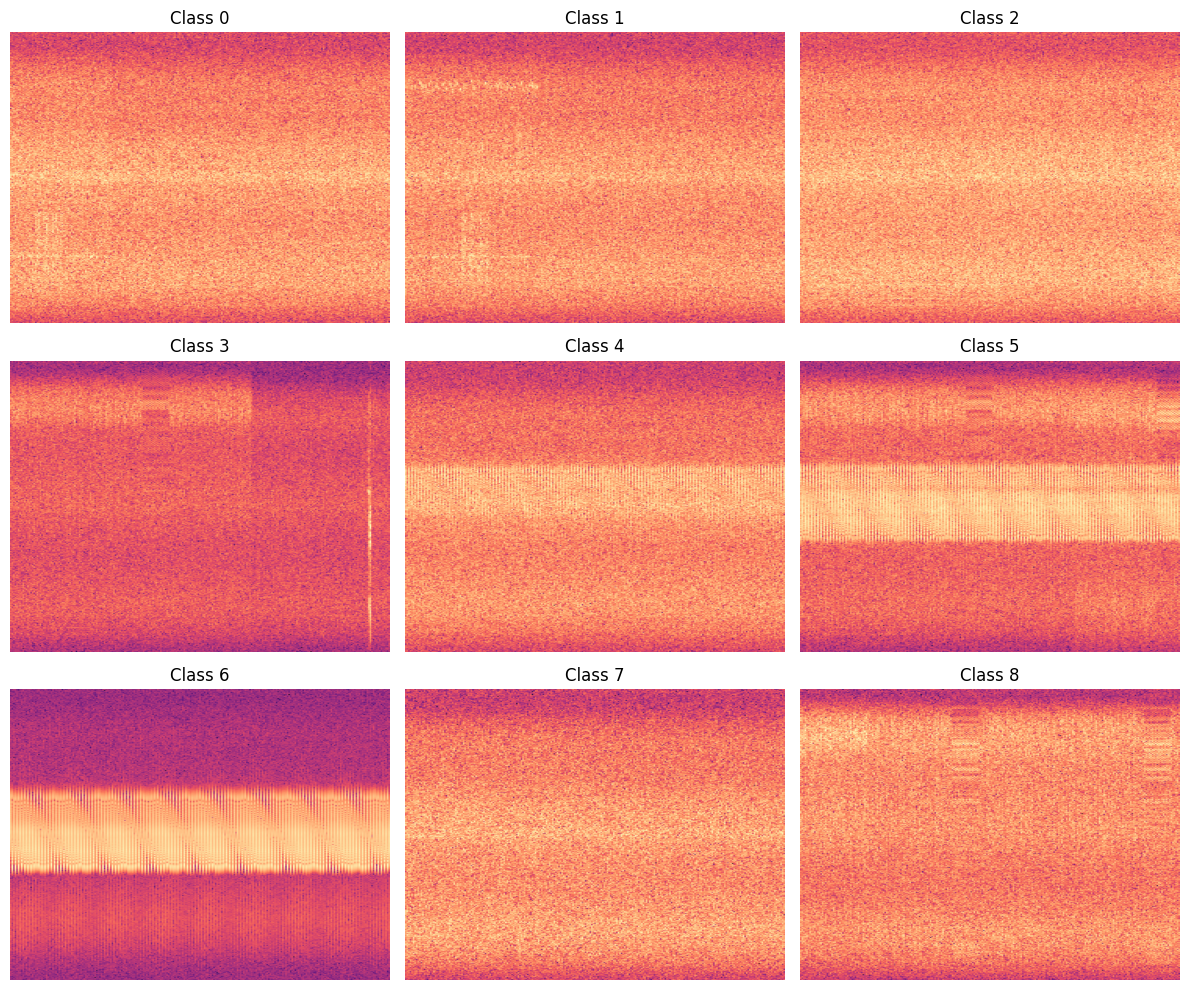

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# Paths (adjust if your notebook is elsewhere)
# -----------------------------------------
base = "/anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main"
train_txt = os.path.join(base, "train.txt")

# -----------------------------------------
# Step 1: Read train.txt and collect 1 file per class
# -----------------------------------------
files_by_class = {i: None for i in range(9)}  # classes 0–8

with open(train_txt, "r") as f:
    for line in f:
        rel_path, label = line.strip().split()
        label = int(label)

        # store first example of each class
        if files_by_class[label] is None:
            files_by_class[label] = os.path.join(base, rel_path)

        # stop early if we have all 9
        if all(files_by_class.values()):
            break

print("Loaded one file per class:")
for k, v in files_by_class.items():
    print(f"  Class {k}: {v}")

# -----------------------------------------
# Step 2: Visualization in a 3×3 grid
# -----------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for cls in range(9):
    path = files_by_class[cls]
    arr = np.load(path)

    ax = axes[cls // 3, cls % 3]
    im = ax.imshow(arr, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f"Class {cls}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# Paths
# -----------------------------------------
base = "/anvil/projects/x-cis220051/corporate/aerospace-rf/fiot_highway2-main"
train_txt = os.path.join(base, "train.txt")

# -----------------------------------------
# Step 1: Initialize accumulators
# -----------------------------------------
class_sums = {}
class_counts = {}

for c in range(9):
    class_sums[c] = None   # will hold sum of images
    class_counts[c] = 0    # number of images seen

# -----------------------------------------
# Step 2: Loop through training file
# -----------------------------------------
with open(train_txt, "r") as f:
    for line in f:
        rel_path, label = line.strip().split()
        label = int(label)
        
        full_path = os.path.join(base, rel_path)
        arr = np.load(full_path)

        # Initialize the accumulator for this class
        if class_sums[label] is None:
            class_sums[label] = np.zeros_like(arr, dtype=np.float64)

        # Add the image to the sum
        class_sums[label] += arr
        class_counts[label] += 1

# -----------------------------------------
# Step 3: Compute the average images
# -----------------------------------------
avg_images = {}

for c in range(9):
    avg_images[c] = class_sums[c] / class_counts[c]
    print(f"Class {c}: {class_counts[c]} samples averaged.")

# -----------------------------------------
# Step 4: Plot all average images in 3x3 grid
# -----------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for c in range(9):
    ax = axes[c // 3, c % 3]
    ax.imshow(avg_images[c], aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(f"Average Image — Class {c}")
    ax.axis("off")

plt.tight_layout()
plt.show()